In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm

import gpytorch

from Functions import EDFA_Modelling, Fibre_ModelLoad
import CustomKernels.LaplacianKernel as LK
import CustomKernels.LaplacianKernelUncertainty as LKUncertain
import CustomKernels.UncertainKernel as UncertainKernel
import CustomKernels.UncertainMeanConstant as UncertainMean
import CustomKernels.UncertainMeanZero as UncertainZeroMean

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

uncertain = False

In [2]:
inputPowers = pd.read_csv("data/EDFA 2/Inputs.csv", index_col=0)
outputPowers = pd.read_csv("data/EDFA 2/Outputs.csv", index_col=0)
perms = pd.read_csv("data/EDFA 2/perms.csv", index_col=0)

EDFA_settings = pd.read_csv("data/EDFA 2/EDFA_setting.csv", index_col=0)
EDFA1_setting = EDFA_settings["0"]

onChannels = perms.copy()
onChannels[onChannels > -1] = 1
onChannels[onChannels == -1] = 0

onChannels = onChannels.to_numpy()

scaledInputs, OutputPowersArr, initialVariance = EDFA_Modelling.preprocess_data(inputPowers, outputPowers, EDFA1_setting, onChannels, uncertain)

### EDFA1 Model

In [3]:
EDFAID = "1"
edfa1_outputs, edfa1_variances = EDFA_Modelling.make_predictions(scaledInputs, initialVariance, uncertain, EDFAID, device)

d:\ch982\OneDrive - University of Cambridge\Documents\JLT 2025\5Spans\Functions\EDFA_Modelling.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load(p

### Fibre 1 Model

In [4]:
fibre1_output, fibre1_variance = Fibre_ModelLoad.fibrePredictions("fibre 1", onChannels, edfa1_outputs, edfa1_variances)

### EDFA12 Model

In [6]:
fibre1_output = pd.DataFrame(fibre1_output)
combinedInputs = pd.concat([fibre1_output, EDFA_settings.iloc[:len(fibre1_output)]], axis=1)

fibre1_variance = pd.DataFrame(fibre1_variance)
fibre1_variance["16"] = 0
fibre1_variance["17"] = 0
fibre1_variance = fibre1_variance.to_numpy()

scalerIn = MinMaxScaler()
scaledInputs = scalerIn.fit_transform(combinedInputs.to_numpy())

### Split Data for EDFA 2 Model

In [8]:
numTraining = 300
testIndex = 300

X_train, y_train, X_test, y_test = EDFA_Modelling.split_data(scaledInputs, OutputPowersArr, numTraining, testIndex, uncertain, fibre1_variance)

### Train EDFA 2 Model

In [10]:
model, likelihood, training_data = EDFA_Modelling.train_model(X_train, y_train, device, uncertain)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:16<00:00,  5.10it/s]


### Evaluate EDFA 2 Model

In [11]:
l1, l2, preds, vars = EDFA_Modelling.test_model(model, likelihood, X_test, y_test, numTraining, uncertain)

In [12]:
l1, l2

(0.0657639430419753, 0.009669186536100252)

In [13]:
EDFA_Modelling.save_model(model, training_data, uncertain, "2")

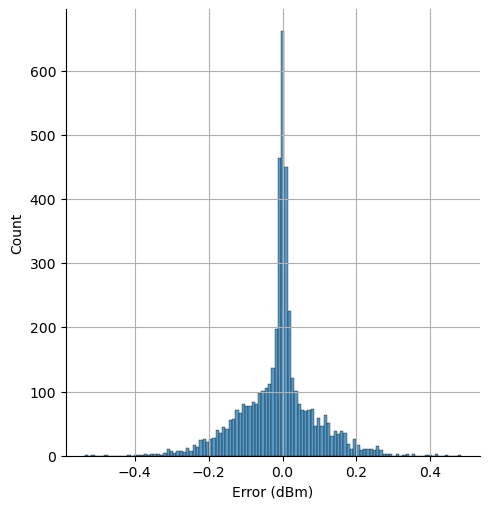

In [14]:
import seaborn as sb
import matplotlib.pyplot as plt

allErrors = sorted((preds - y_test.cpu().numpy()[:len(preds)]).flatten())
sb.displot(allErrors)
plt.xlabel("Error (dBm)")
plt.grid()